In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,age,study_hours,attendance,previous_score,assignments,internal_marks,sleep_hours,internet_usage,final_score,gender_Male,extra_activities_Yes,parent_education_School,family_income_Low,family_income_Medium
0,22,6.3,96,83,85,73,5.5,2.2,39.8,True,False,False,True,False
1,22,4.4,73,59,89,39,7.3,6.0,30.2,False,False,False,False,True
2,22,9.7,71,75,83,99,8.7,5.7,42.1,True,False,True,False,True
3,22,8.6,54,48,98,47,8.4,7.8,34.2,True,False,False,False,False
4,21,8.5,82,77,82,87,7.8,6.3,41.2,True,True,False,True,False


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      450 non-null    int64  
 1   study_hours              450 non-null    float64
 2   attendance               450 non-null    int64  
 3   previous_score           450 non-null    int64  
 4   assignments              450 non-null    int64  
 5   internal_marks           450 non-null    int64  
 6   sleep_hours              450 non-null    float64
 7   internet_usage           450 non-null    float64
 8   final_score              450 non-null    float64
 9   gender_Male              450 non-null    bool   
 10  extra_activities_Yes     450 non-null    bool   
 11  parent_education_School  450 non-null    bool   
 12  family_income_Low        450 non-null    bool   
 13  family_income_Medium     450 non-null    bool   
dtypes: bool(5), float64(4), in

,age,study_hours,attendance,previous_score,assignments,internal_marks,sleep_hours,internet_usage,final_score
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,19.513333,5.292222,74.980000,67.044444,67.935556,66.066667,6.482222,4.520222,32.413778
std,1.701840,2.551554,14.158884,16.099158,17.186073,18.801151,1.441647,2.050947,4.917519
min,17.000000,1.000000,50.000000,40.000000,40.000000,35.000000,4.000000,1.000000,20.600000
25%,18.000000,3.025000,63.000000,52.250000,53.000000,50.000000,5.400000,2.825000,29.100000
50%,20.000000,5.200000,75.000000,67.000000,67.000000,65.000000,6.500000,4.500000,32.100000
75%,21.000000,7.475000,87.000000,81.000000,82.000000,82.000000,7.700000,6.300000,35.900000
max,22.000000,10.000000,99.000000,94.000000,99.000000,99.000000,9.000000,8.000000,45.400000


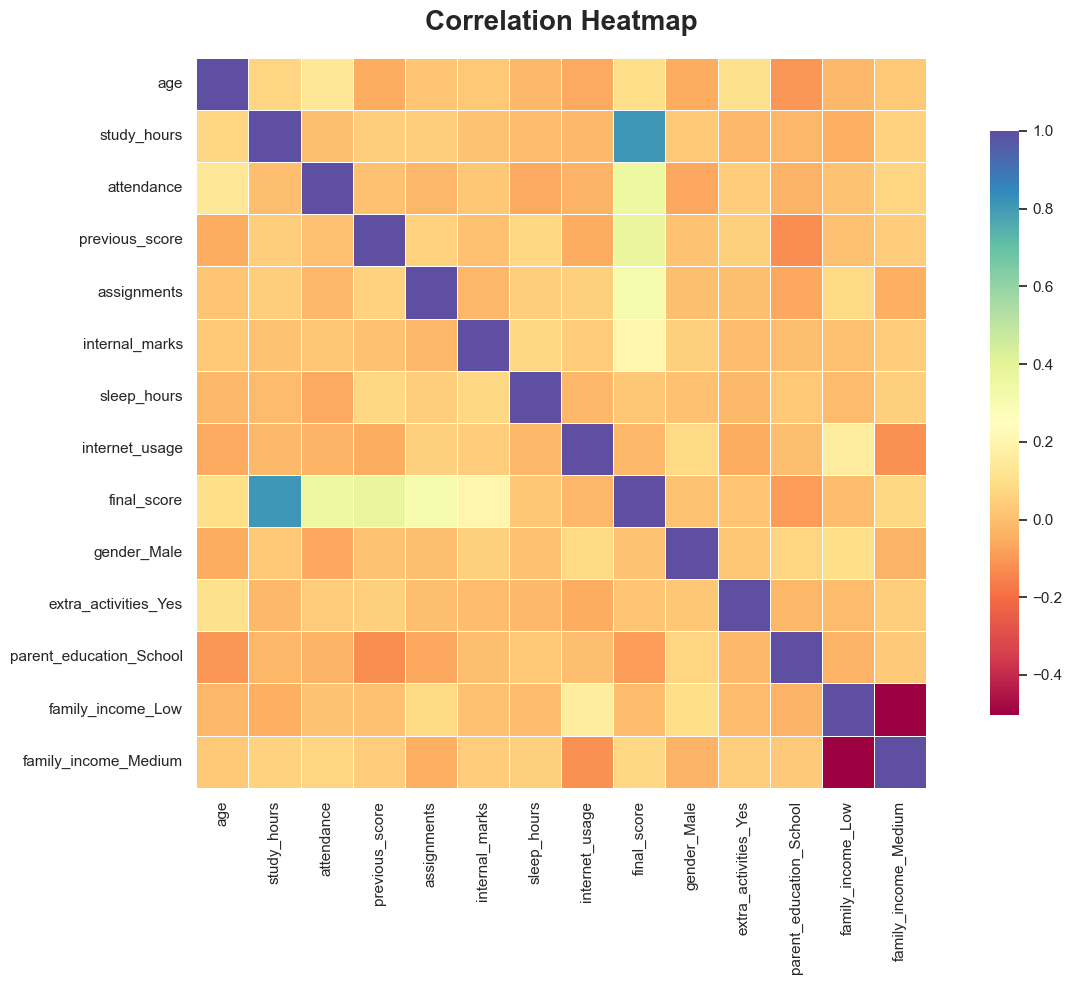

In [12]:
#Correlation Heatmap
# Style (premium look)
sns.set_theme(style="white")

plt.figure(figsize=(14, 10))

# Correlation matrix
corr = df.corr()

# Heatmap
sns.heatmap(
    corr,
    cmap="Spectral",
    annot=False,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    square=True
)

# Title styling
plt.title("Correlation Heatmap", fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

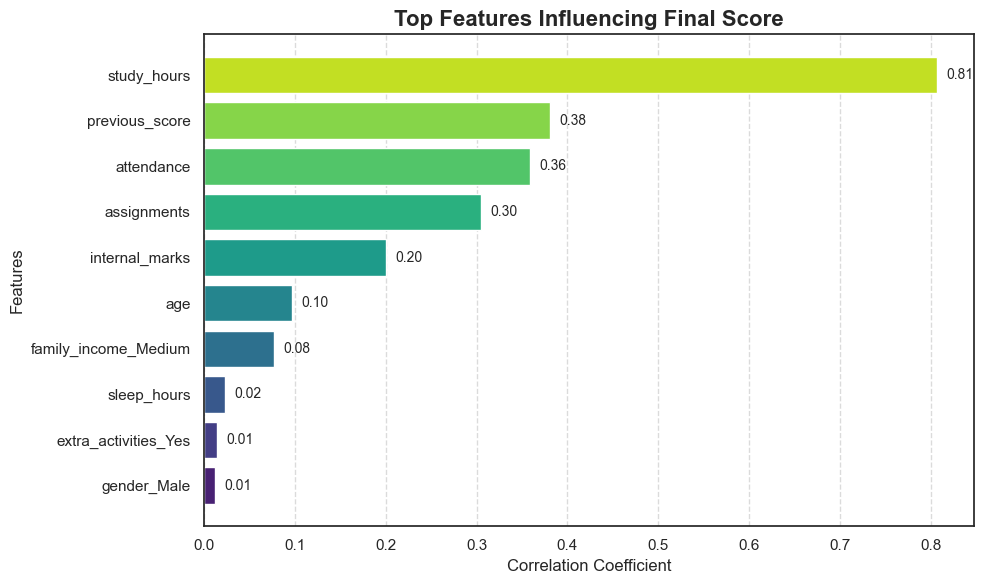

In [13]:
#Top Correlated Features with Target
# Correlation with target
corr_target = df.corr()['final_score'].drop('final_score').sort_values(ascending=True)

# Select top 10 features
top_features = corr_target.tail(10)

# Plot
plt.figure(figsize=(10, 6))

colors = sns.color_palette("viridis", len(top_features))

bars = plt.barh(top_features.index, top_features.values, color=colors)

# Add value labels
for i, v in enumerate(top_features.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

# Title & labels
plt.title("Top Features Influencing Final Score", fontsize=16, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

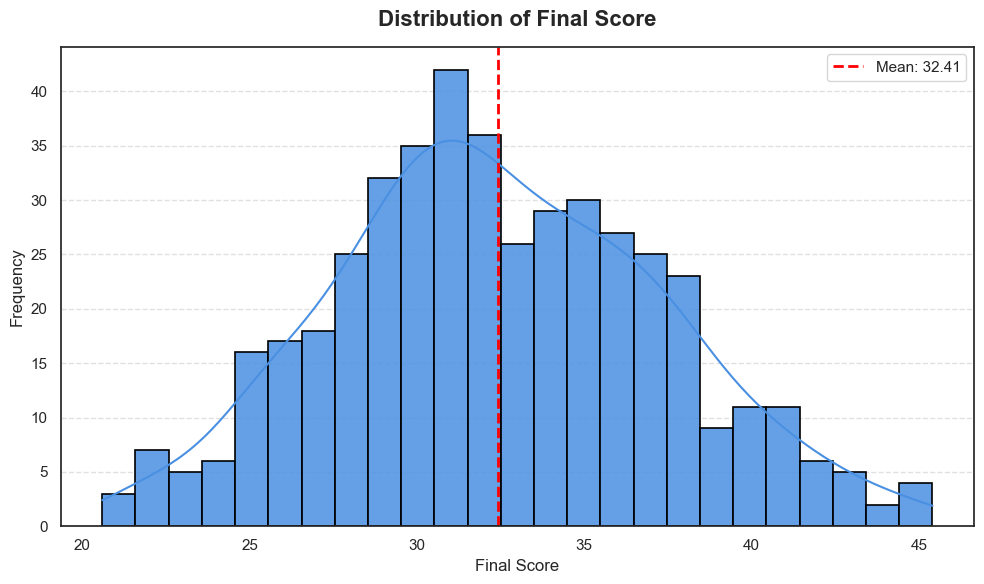

In [14]:
#Distribution Plot (Target Variable)
plt.figure(figsize=(10, 6))

sns.histplot(
    df['final_score'],
    bins=25,
    kde=True,
    color="#4A90E2",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85
)

# Mean line (pro touch)
mean_val = df['final_score'].mean()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")

# Titles & labels
plt.title("Distribution of Final Score", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Final Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Legend
plt.legend()

# Grid styling
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

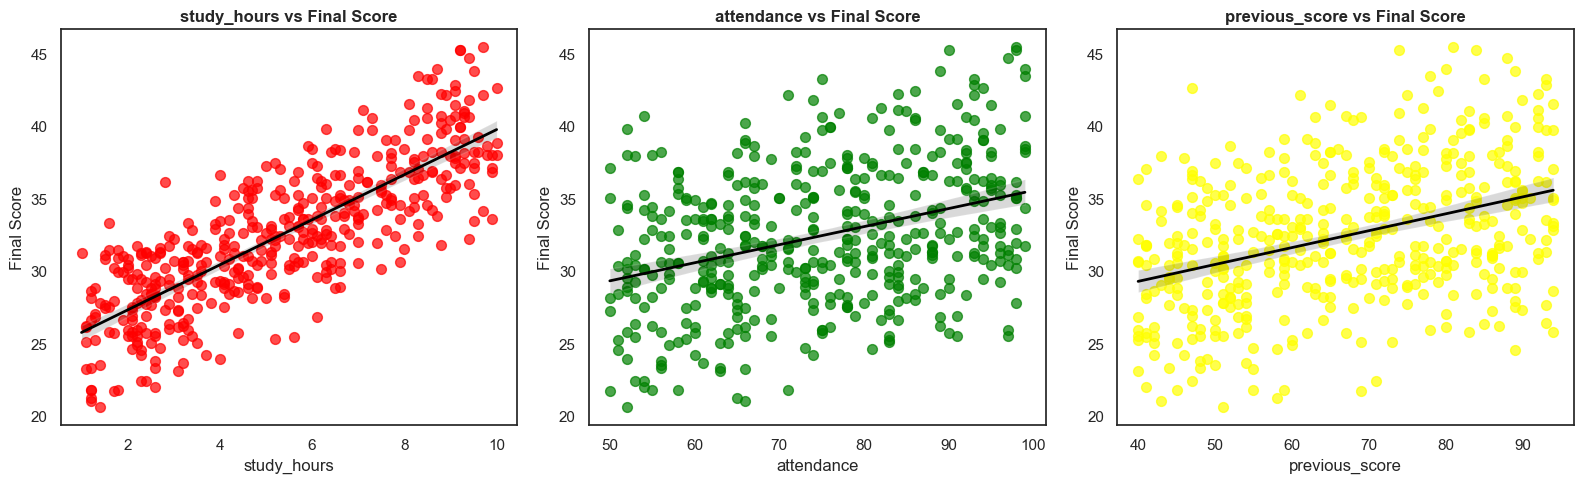

In [17]:
#Scatter Plots (Important Relationships)
features = ['study_hours', 'attendance', 'previous_score']

# Premium color palette
colors = ["red", "green", "yellow"]

plt.figure(figsize=(16, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    
    sns.regplot(
        x=df[col],
        y=df['final_score'],
        scatter_kws={"color": colors[i], "alpha": 0.7, "s": 50},
        line_kws={"color": "black", "linewidth": 2}
    )
    
    plt.title(f"{col} vs Final Score", fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Final Score")

plt.tight_layout()
plt.show()

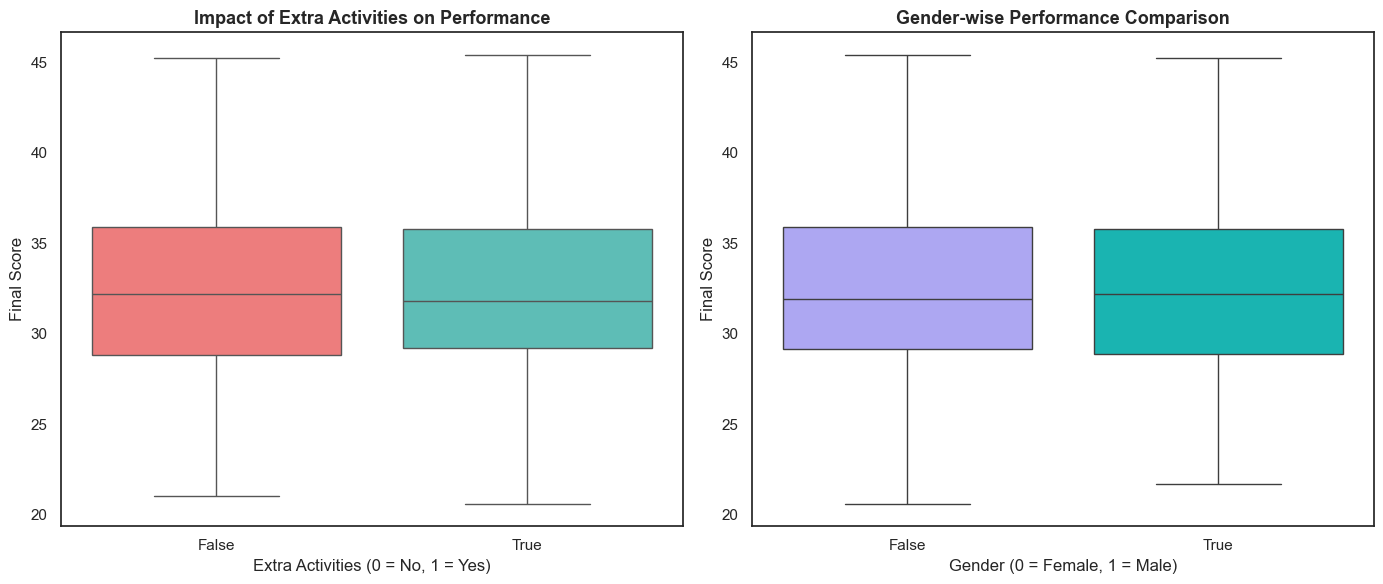

In [20]:
plt.figure(figsize=(14, 6))

# Plot 1: Extra Activities
plt.subplot(1, 2, 1)
sns.boxplot(
    x=df['extra_activities_Yes'],
    y=df['final_score'],
    hue=df['extra_activities_Yes'], 
    palette=["#FF6B6B", "#4ECDC4"],
    legend=False
)
plt.title("Impact of Extra Activities on Performance", fontsize=13, fontweight='bold')
plt.xlabel("Extra Activities (0 = No, 1 = Yes)")
plt.ylabel("Final Score")

# Plot 2: Gender
plt.subplot(1, 2, 2)
sns.boxplot(
    x=df['gender_Male'],
    y=df['final_score'],
    hue=df['gender_Male'], 
    palette=["#A29BFE", "#00CEC9"],
    legend=False
)
plt.title("Gender-wise Performance Comparison", fontsize=13, fontweight='bold')
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Final Score")

plt.tight_layout()
plt.show()

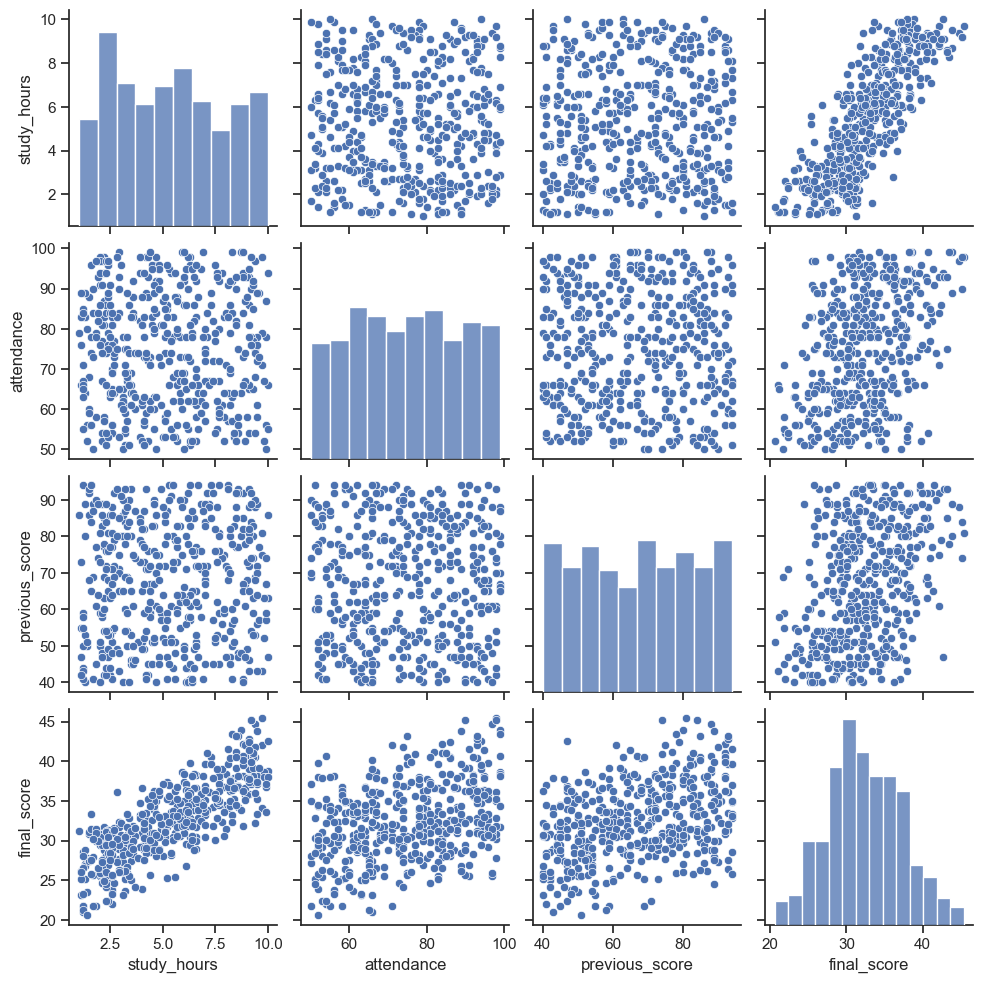

In [22]:
#Pairplot
sns.pairplot(df[['study_hours', 'attendance', 'previous_score', 'final_score']])
plt.show()

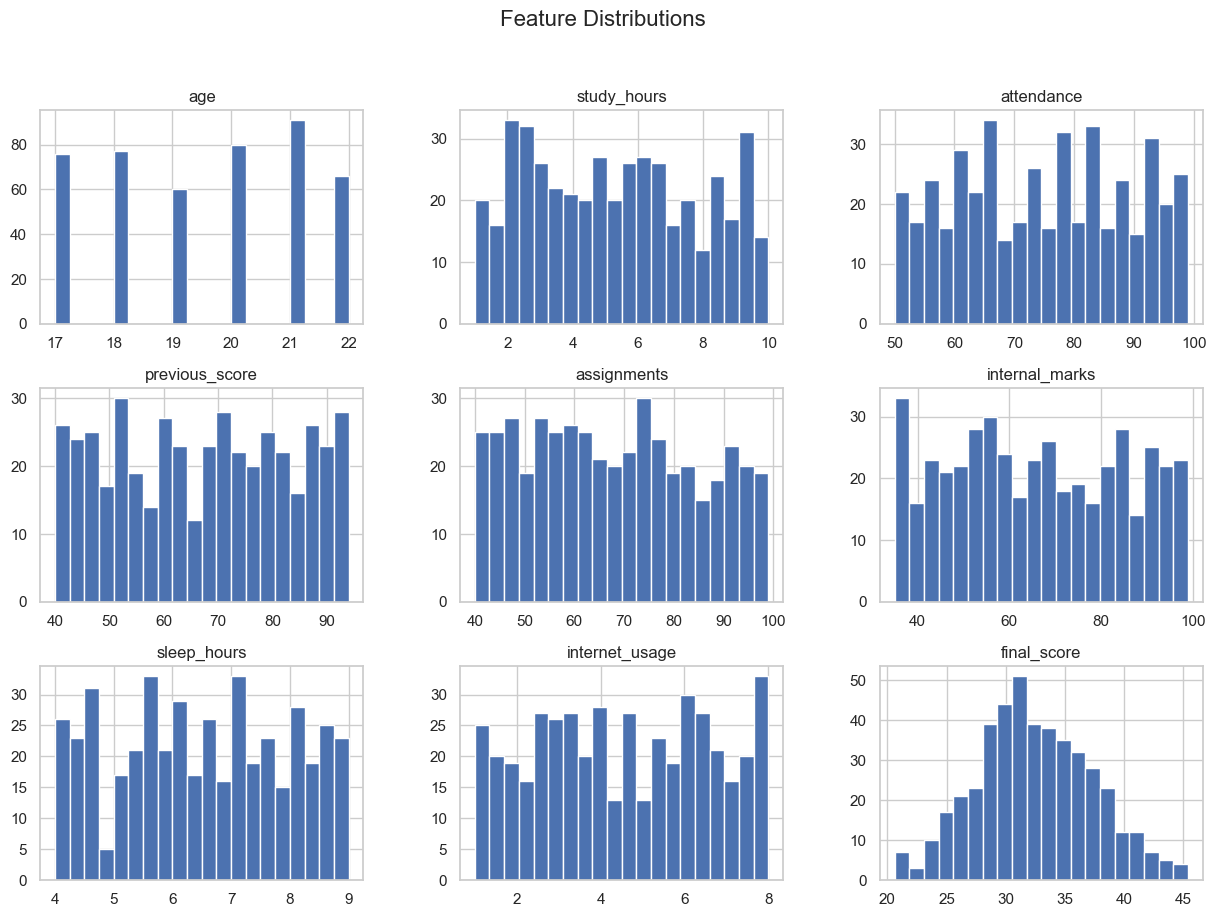

In [11]:
#Feature Distribution
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()